Figure | Description
:- | :-------
Supplementary 1 | schematic of the model, parametrisation and fit at each step
Supplementary 2 | unvaccinated cohorts at 0.5, 1, 2 and 10 infections per year
Supplementary 3A | validation using RTS,S with and without 1 booster
Supplementary 3B | validation using R21 with and without SMC (datoo)
Supplementary 4 | R21 for 2 years and RTS,S for 2 years 
Figure 1 | R21 for 2 years, R21+SMC for 2 years and R21+SMC for 5 years
Figure 2 | RH5 for 2 years, RH5 with x 2 half-life for 2 years and RH5 with x 2 half-life for 5 years
Supplementary 5 | as figure 2 but RH5 protects against blood infection
Figure 3 | R21, RH5 and R21+RH5 for 2 years 
Supplementary 6 | as figure 3 but for 5 years
Figure 4 | lifetime episodes averted and efficacies across transmission intensities. R21, RH5 and R21+RH5 for 2 years
Supplementary 7 | as figure 4 but for 5 years
Supplementary 8 | as figure S7 but for perennial transmission
Figure 5 | R21 rescue, R21+SMC for 5 years or R21+SMC for 5 years followed by RH5 with no boosters or R21+SMC for 5 years followed by RH5 with 1 booster

{{< pagebreak >}}

In [3]:
import graphviz
import pickle
import matplotlib as mpl

mpl.rcParams['xtick.major.size'] = 0
mpl.rcParams['ytick.major.size'] = 0
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['grid.alpha'] = 0.5

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica Neue']

mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['savefig.format'] = 'svg'

from Scripts import paper
λ = 3
β = 1
years = 26
seasonal_season_width = 0.11
perennial_season_width = 0.43

fig_xscale=1.1
fig_yscale=0.7

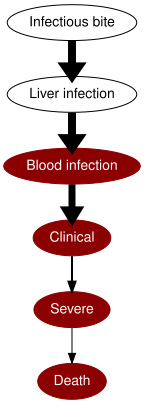

In [7]:
#| output: false

g = graphviz.Digraph(filename='model', strict=True, directory='Figures', format='svg')

g.node('Blood infection', style='filled', color='DarkRed', fillcolor='DarkRed', fontname='Helvetica', fontcolor='White')
g.node('Infectious bite', fontname='Helvetica')
g.node('Liver infection', fontname='Helvetica')
g.edge('Infectious bite', 'Liver infection', penwidth='8')
g.edge('Liver infection', 'Blood infection', penwidth='8')

g.node('Clinical', style='filled', color='DarkRed', fillcolor='DarkRed', fontcolor='White', fontname="Helvetica")
g.edge('Blood infection', 'Clinical', penwidth='7', weight='2')

g.node('Severe', style='filled', color='DarkRed', fillcolor='DarkRed', fontcolor='White', fontname='Helvetica')
g.edge('Clinical', 'Severe', penwidth='2', weight='2')

g.node('Death', style='filled', color='DarkRed', fillcolor='DarkRed', fontcolor='White', fontname='Helvetica')
g.edge('Severe', 'Death', weight='2', penwidth='1')

g.render()
g

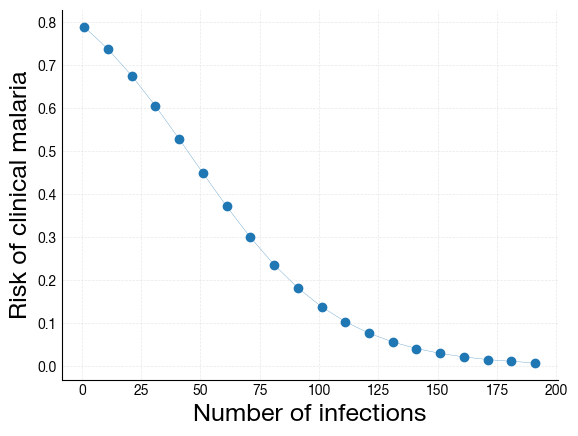

In [31]:
#| output: false

fig, ax = paper.clinical_malaria_risk_plot(fontsize=18)
fig.savefig('Figures/clinical_immunity_risk.svg')

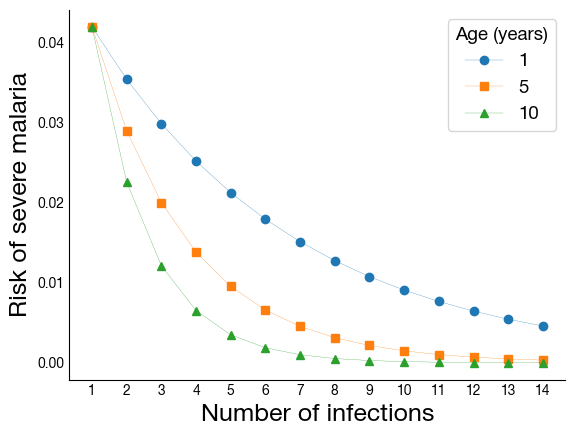

In [32]:
#| output: false

fig, ax = paper.severe_malaria_risk_plot(fontsize=18)
fig.savefig('Figures/severe_immunity_risk.svg')

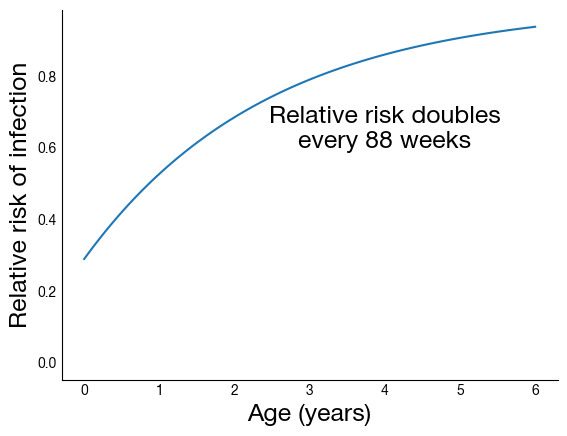

In [33]:
#| output: false

fig, ax = paper.early_life_protection_plot(fontsize=18)
fig.savefig('Figures/early_life_protection.svg')

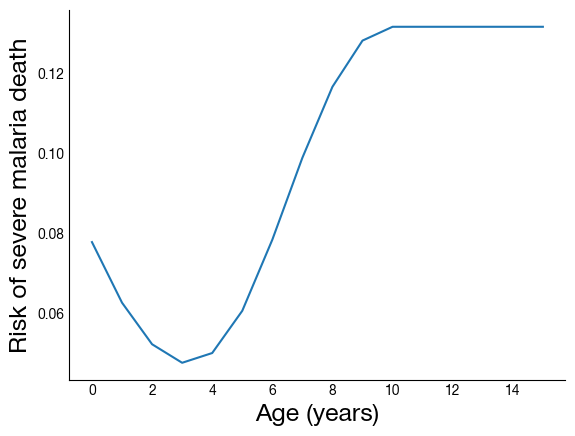

In [34]:
#| output: false

from Scripts import reyburn
gam = reyburn.fit_GAM1()
XX, fit, death_rates, cis = reyburn.death_rate_mean_CI(gam)
fig, ax = reyburn.plot_GAM_mean(death_rates)

fig.savefig('Figures/reyburn_2015_mort_GAM')

# Supplementary figure 2

- Unvaccinated cohorts

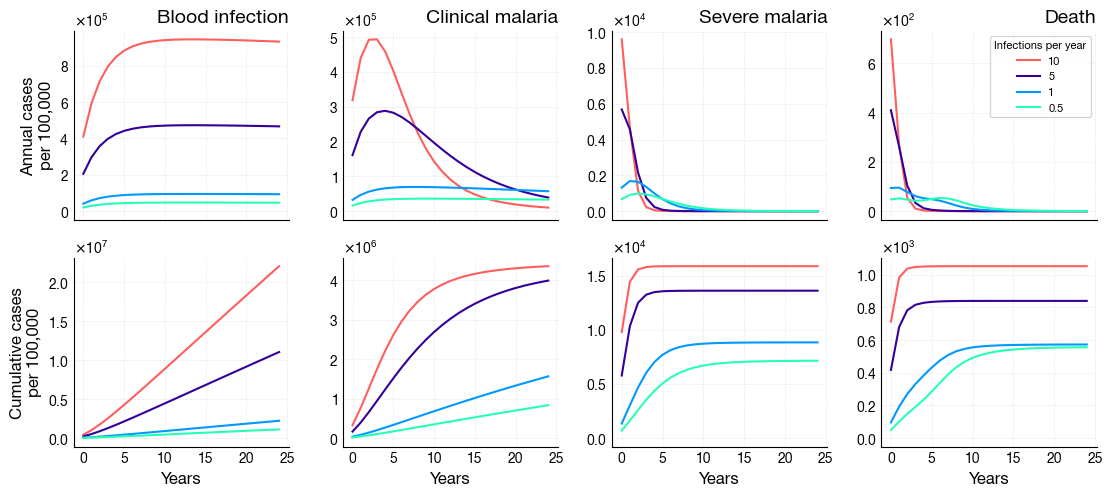

In [9]:
fig, axs = paper.unvaccinated(years=years, β=β, season_width=1, fig_xscale=fig_xscale, fig_yscale=0.9)
fig.savefig('Figures/figS2')

{{< pagebreak >}}

# Supplementary figure 3A

- RTS,S validation

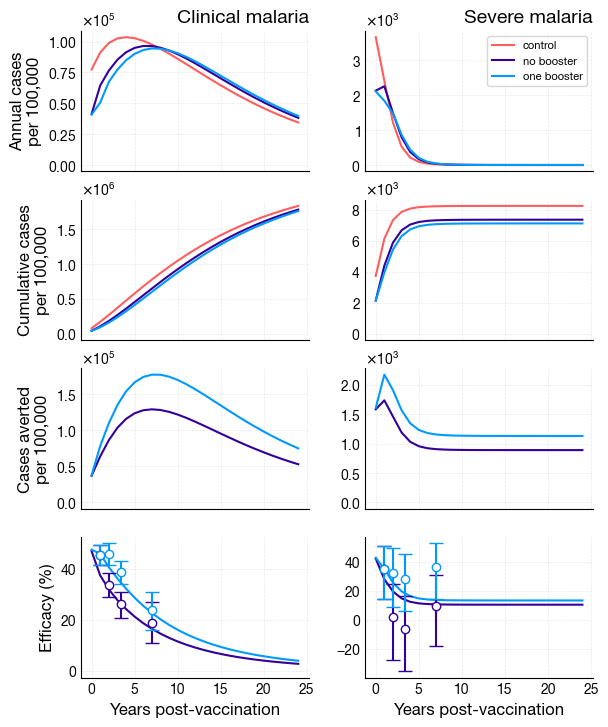

In [6]:
fig, axs = paper.RTSS_validate_ts(λ=λ, β=β, years=26, fig_xscale=fig_xscale, fig_yscale=fig_yscale)
fig.savefig('Figures/figS3A')

{{< pagebreak >}}

# Supplementary figure 3B

- R21 validation

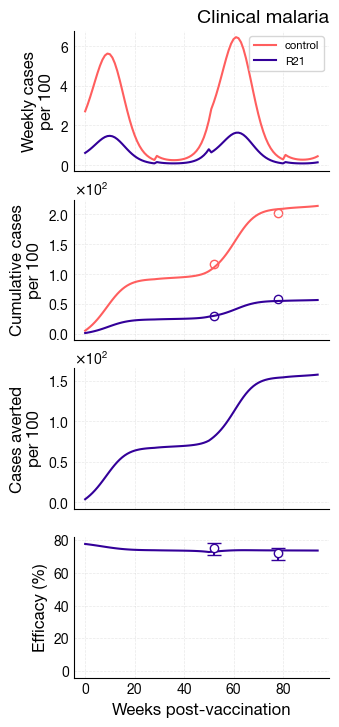

In [15]:
fig, axs = paper.R21_validate_ts(fig_xscale=fig_xscale, fig_yscale=fig_yscale)
fig.savefig('Figures/figS3B')

{{< pagebreak >}}

# Supplementary figure 4

- R21 for 2 years
- RTS,S for 2 years

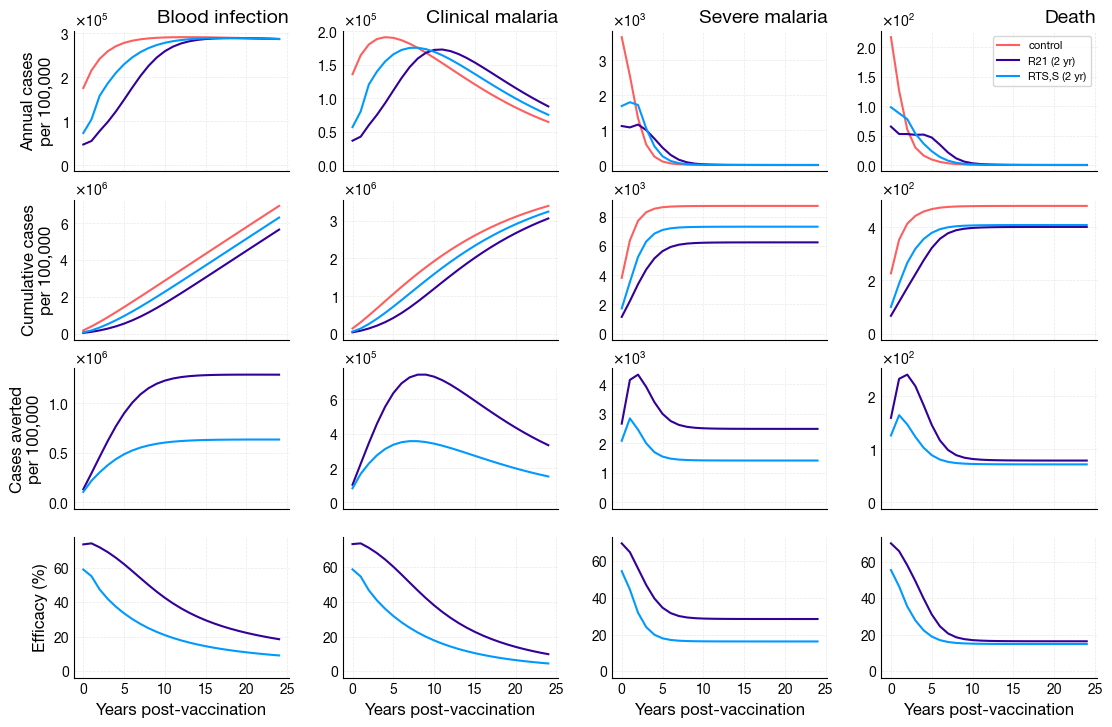

In [12]:
fig, axs = paper.RTSS_or_R21_ts(λ=λ, β=β, season_width=seasonal_season_width, years=years, fig_xscale=fig_xscale, fig_yscale=fig_yscale)
fig.savefig('Figures/figS4')

{{< pagebreak >}}

# Figure 1

- R21 for two years
- R21+SMC for two years
- R21+SMC for five years

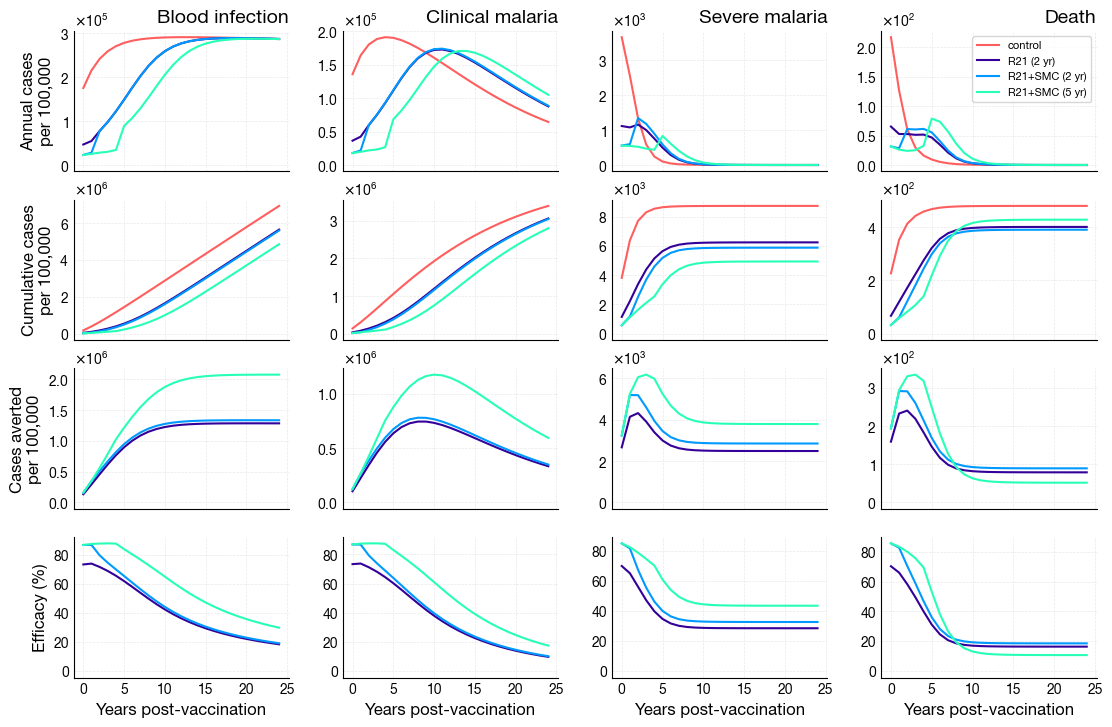

In [11]:
fig, axs = paper.R21_or_R21_and_SMC_ts(λ=λ, β=β, season_width=seasonal_season_width, years=years, fig_xscale=fig_xscale, fig_yscale=fig_yscale)
fig.savefig('Figures/fig1')

{{< pagebreak >}}

# Figure 2: 

RH5.1 does not reduce the risk of blood infection

- RH5.1 for two years
- RH5.1 with x 2 half-life for two years
- RH5.1 with x 2 half-life for five years

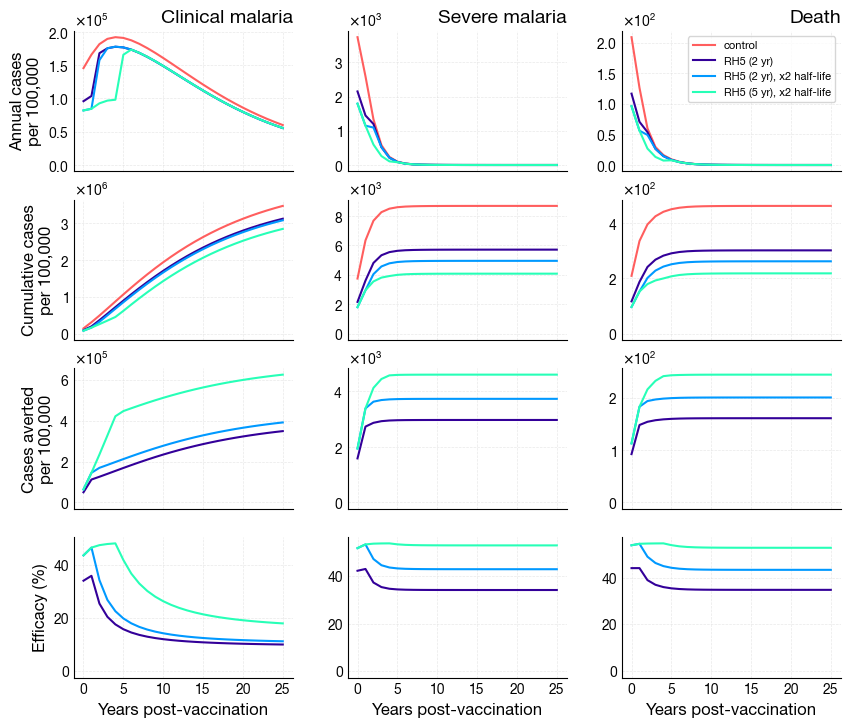

In [14]:
fig, axs = paper.RH5_ts(λ=λ, β=β, season_width=seasonal_season_width, years=years, fig_xscale=fig_xscale, fig_yscale=fig_yscale)
fig.savefig('Figures/fig2')

{{< pagebreak >}}

# Supplementary figure 5: 

RH5 reduces the risk of blood infection

- RH5 for two years
- RH5 with x 2 half-life for two years
- RH5 with x 2 half-life for five years

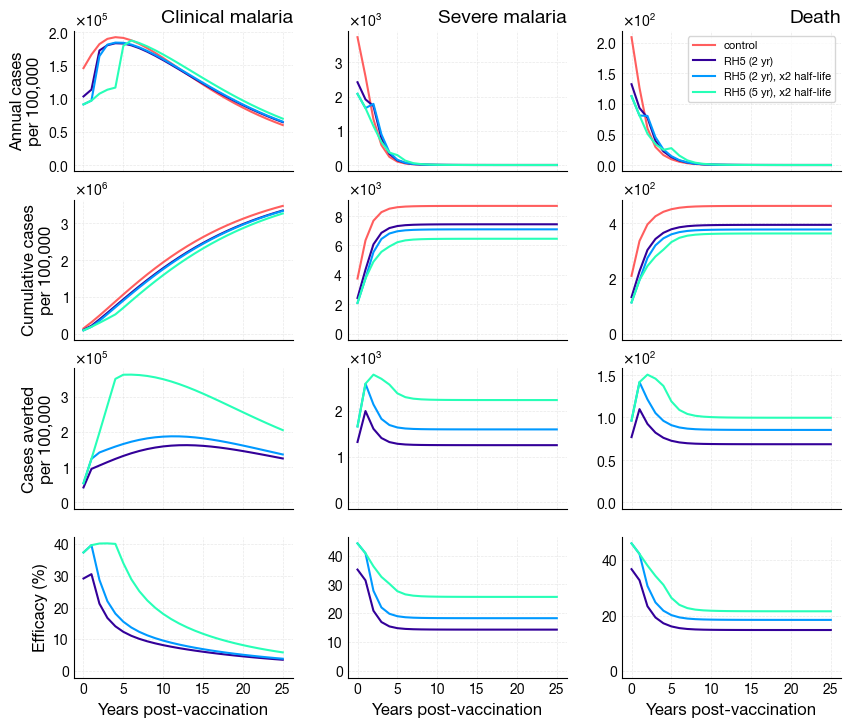

In [15]:
fig, axs = paper.RH5_ts(λ=λ, β=β, season_width=seasonal_season_width, years=years, fig_xscale=fig_xscale, fig_yscale=fig_yscale, protection_blood=True)
fig.savefig('Figures/figS5')

{{< pagebreak >}}

# Figure 3

- R21 for two years
- RH5.1 for two years
- RH5.1+R21 simultaneously for two years

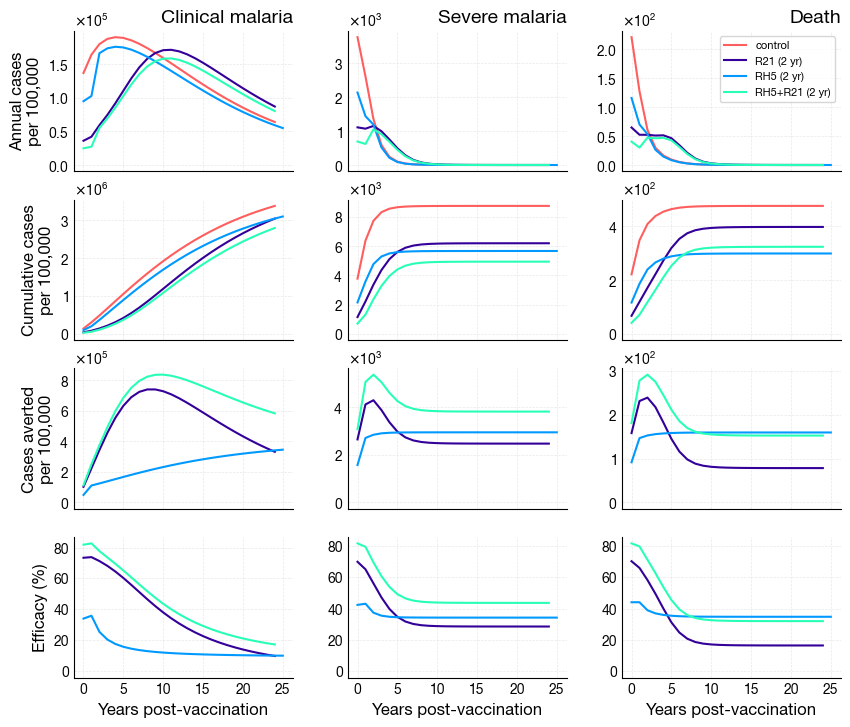

In [16]:
fig, axs = paper.RH5_R21_ts(λ=λ, β=β, season_width=seasonal_season_width, years=years, boosters=1, fig_xscale=fig_xscale, fig_yscale=fig_yscale)
fig.savefig('Figures/fig3')

{{< pagebreak >}}

# Supplementary figure 6

As Figure 3 but for five years

- R21 for five years
- RH5 for five years
- RH5+R21 simultaneously for five years

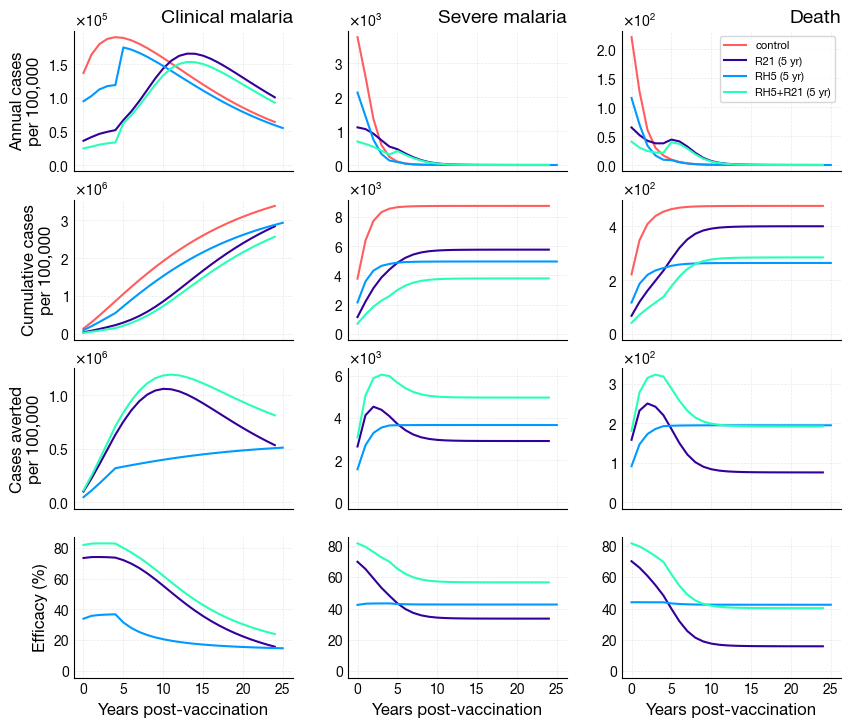

In [17]:
fig, axs = paper.RH5_R21_ts(λ=λ, β=β, season_width=seasonal_season_width, years=years, boosters=4, fig_xscale=fig_xscale, fig_yscale=fig_yscale)
fig.savefig('Figures/figS6')

{{< pagebreak >}}

# Figure 4

- R21, two years
- RH5.1, two years
- R21+RH5.1 simultaneously, two years

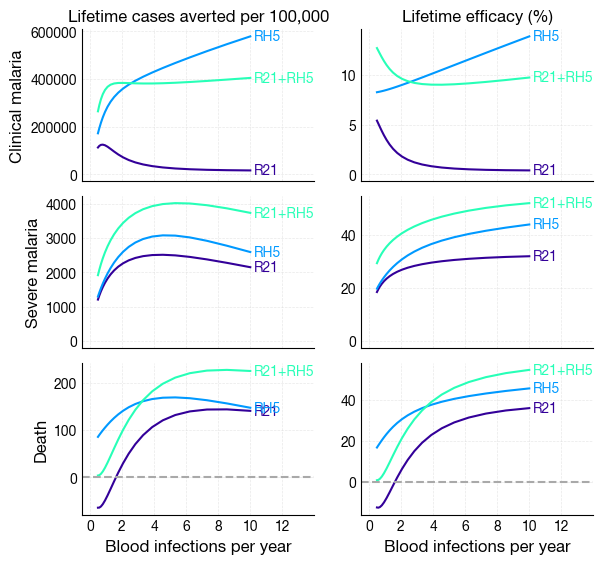

In [ ]:
# two_years = paper.lifetime_efficacies(years=90, β=β, season_width=seasonal_season_width, boosters=1, smc=False, protection_blood=False)
# with open('Data/two_years.pkl', 'wb') as f:
#     pickle.dump(two_years, f)

with open('Data/two_years.pkl', 'rb') as f:
    two_years = pickle.load(f)

fig, axs = paper.lifetime_efficacies_plot(two_years, fig_xscale=fig_xscale, fig_yscale=fig_yscale, surveyed=False)
fig.savefig('Figures/fig4')

{{< pagebreak >}}

# Supplementary figure 7

As Fig. 4 but vaccination for five years

- R21, five years
- RH5.1, five years
- R21+RH5.1 simultaneously, five years

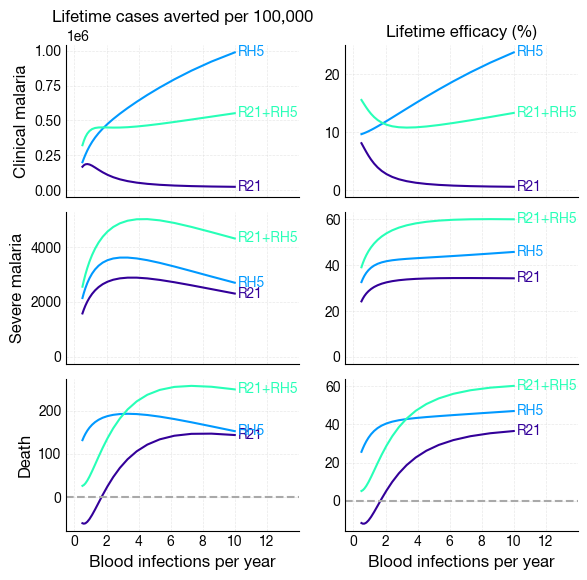

In [22]:
# five_years = paper.lifetime_efficacies(years=90, β=β, season_width=seasonal_season_width, boosters=4, smc=False, protection_blood=False)
# with open('Data/five_years.pkl', 'wb') as f:
#     pickle.dump(five_years, f)

with open('Data/five_years.pkl', 'rb') as f:
    five_years = pickle.load(f)

fig, axs = paper.lifetime_efficacies_plot(five_years, fig_xscale=fig_xscale, fig_yscale=fig_yscale, surveyed=False)
fig.savefig('Figures/figS7')

{{< pagebreak >}}

# Supplementary figure 8

As Fig. S7 but perennial transmission.

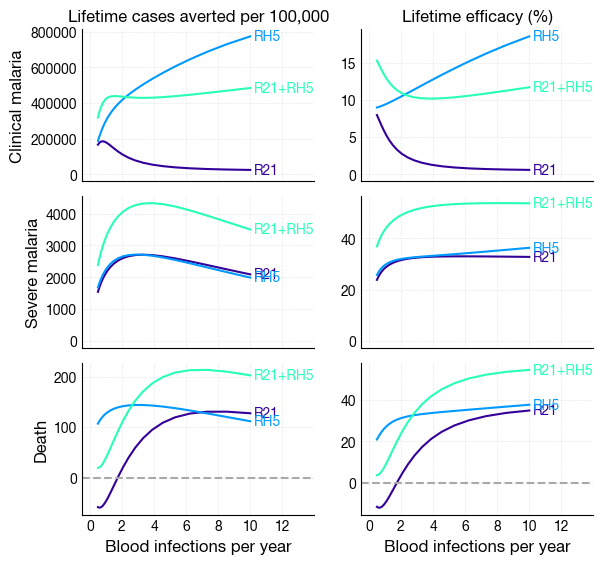

In [23]:
# five_years_perennial = paper.lifetime_efficacies(years=90, β=β, season_width=perennial_season_width, boosters=4, smc=False, protection_blood=False)
# with open('Data/five_years_perennial.pkl', 'wb') as f:
#     pickle.dump(five_years_perennial, f)

with open('Data/five_years_perennial.pkl', 'rb') as f:
    five_years_perennial = pickle.load(f)

fig, axs = paper.lifetime_efficacies_plot(five_years_perennial, fig_xscale=fig_xscale, fig_yscale=fig_yscale, surveyed=False)
fig.savefig('Figures/figS8')

{{< pagebreak >}}

# Figure 5

Rescuing R21 with RH5.1.

- R21 alone for two years
- R21 + SMC for two years
- R21 + SMC for five years

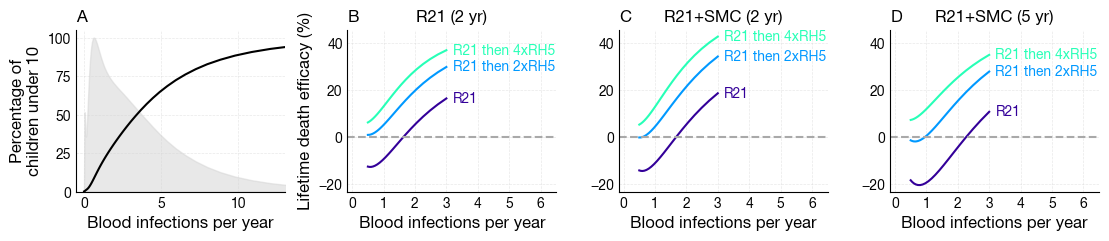

In [3]:
# r21_2 = paper.R21_rescue('R21 (2 yr)', β=β, season_width=seasonal_season_width, boosters=1, smc=False)
# r21_smc_2 = paper.R21_rescue('R21+SMC (2 yr)', β=β, season_width=seasonal_season_width, boosters=1, smc=True)
# r21_smc_5 = paper.R21_rescue('R21+SMC (5 yr)', β=β, season_width=seasonal_season_width, boosters=4, smc=True)
# with open('Data/r21_rescue.pkl', 'wb') as f:
#     pickle.dump((r21_2, r21_smc_2, r21_smc_5), f)

with open('Data/r21_rescue.pkl', 'rb') as f:
    r21_2, r21_smc_2, r21_smc_5 = pickle.load(f)

fig, axs = paper.R21_rescue_plot((r21_2, r21_smc_2, r21_smc_5), fig_xscale=fig_xscale, fig_yscale=fig_yscale, surveyed=True)
fig.savefig('Figures/fig5')